In [1]:
# ===========================================================
# === 1. Imports ===
# ===========================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    average_precision_score, precision_recall_curve, ConfusionMatrixDisplay)
import xgboost as xgb
# Suppress minor warnings for cleaner output
warnings.filterwarnings('ignore')

In [2]:
DATA_PATH = 'CVD_cleaned.csv'

# ---- Target column ----
TARGET_COL = 'Heart_Disease'

# ---- Model save paths ----
MODEL_SAVE_PATH   = 'cvd_xgboost_model.joblib'
SCALER_SAVE_PATH  = 'cvd_scaler.joblib'
ENCODER_SAVE_PATH = 'cvd_label_encoders.joblib'

# ---- Train/test split ----
TEST_SIZE    = 0.20   # 20% for testing, 80% for training
RANDOM_STATE = 42     # For reproducibility

# ---- XGBoost hyperparameters ----
XGB_PARAMS = {
    'n_estimators'    : 300,
    'max_depth'       : 6,
    'learning_rate'   : 0.05,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'gamma'           : 0.1,
    'reg_alpha'       : 0.1,
    'reg_lambda'      : 1.0,
    'eval_metric'     : 'auc',
    'random_state'    : RANDOM_STATE,
    'n_jobs'          : -1,       # Use all CPU cores
    'tree_method'     : 'hist',   # Fast method for large datasets
}

# ---- Downsampling config (used in Cell 6) ----
DOWNSAMPLE      = False       # Set True to speed up experiments
DOWNSAMPLE_SIZE = 80_000      # Rows to keep if downsampling

# ---- Plot style ----
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

In [3]:
df_raw = pd.read_csv(DATA_PATH)

print(f"\n{'='*55}")
print(f"  DATASET OVERVIEW")
print(f"{'='*55}")
print(f"  Shape        : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"  Memory usage : {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print(f"\n--- Column Names & Data Types ---")
for col in df_raw.columns:
    print(f"  - {col}: {df_raw[col].dtype}")

print(f"\n--- First 3 Rows ---")
print(df_raw.head(3).to_string())

print(f"\n--- Descriptive Statistics ---")
print(df_raw.describe().to_string())

print(f"\n--- Missing Values ---")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].to_string()
      if missing.sum() > 0 else "  No missing values found.")

# Keep a working copy so df_raw stays untouched
df = df_raw.copy()

# --- Standardize target column name ---
# If your CSV has a different target column name, update TARGET_COL in Cell 2
if TARGET_COL not in df.columns:
    print(f"\n[ERROR] Column '{TARGET_COL}' not found!")
    print(f"  Available columns: {df.columns.tolist()}")
    raise KeyError(f"Target column '{TARGET_COL}' not found. Update TARGET_COL in Cell 2.")

df = df.rename(columns={TARGET_COL: 'target'})

# Ensure target is binary integer (0 / 1)
# Handles: 'Yes'/'No', 'High'/'Low', True/False, 1.0/0.0
unique_vals = df['target'].unique()
print(f"\n[INFO] Unique values in target column: {unique_vals}")

if df['target'].dtype == object or not set(unique_vals).issubset({0, 1, 0.0, 1.0}):
    yes_no_map = {
        'Yes': 1, 'No': 0, 'yes': 1, 'no': 0,
        'High': 1, 'Low': 0, True: 1, False: 0,
        1.0: 1, 0.0: 0
    }
    df['target'] = df['target'].map(yes_no_map).astype(int)
    print(f"[INFO] Target mapped to binary. New unique values: {df['target'].unique()}")
else:
    df['target'] = df['target'].astype(int)

print(f"\n[INFO] Target value counts:")
print(df['target'].value_counts().to_string())


  DATASET OVERVIEW
  Shape        : 308,854 rows x 19 columns
  Memory usage : 206.3 MB

--- Column Names & Data Types ---
  - General_Health: object
  - Checkup: object
  - Exercise: object
  - Heart_Disease: object
  - Skin_Cancer: object
  - Other_Cancer: object
  - Depression: object
  - Diabetes: object
  - Arthritis: object
  - Sex: object
  - Age_Category: object
  - Height_(cm): float64
  - Weight_(kg): float64
  - BMI: float64
  - Smoking_History: object
  - Alcohol_Consumption: float64
  - Fruit_Consumption: float64
  - Green_Vegetables_Consumption: float64
  - FriedPotato_Consumption: float64

--- First 3 Rows ---
  General_Health                  Checkup Exercise Heart_Disease Skin_Cancer Other_Cancer Depression Diabetes Arthritis     Sex Age_Category  Height_(cm)  Weight_(kg)    BMI Smoking_History  Alcohol_Consumption  Fruit_Consumption  Green_Vegetables_Consumption  FriedPotato_Consumption
0           Poor  Within the past 2 years       No            No          No     


  CLASS DISTRIBUTION
  0 — Low Risk  : 283,883  (91.9%)
  1 — High Risk :  24,971  (8.1%)

  Imbalance Ratio (Low:High) = 11.4:1
  [WARN] Dataset is imbalanced!
  [WARN] Will use scale_pos_weight in XGBoost to handle this.


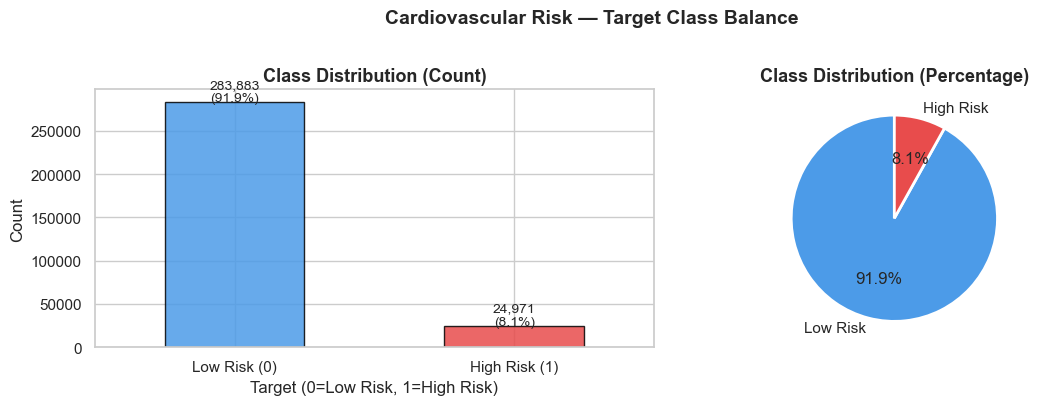


[INFO] Class distribution plot saved as 'class_distribution.png'
[INFO] Cell 4 complete!


In [4]:
# ===========================================================
# === 4. Class Distribution & Imbalance Check ===
# ===========================================================

# Count how many patients are High Risk (1) and Low Risk (0)
target_counts = df['target'].value_counts()
target_pct    = df['target'].value_counts(normalize=True) * 100

print(f"\n{'='*45}")
print(f"  CLASS DISTRIBUTION")
print(f"{'='*45}")
print(f"  0 — Low Risk  : {target_counts[0]:>7,}  ({target_pct[0]:.1f}%)")
print(f"  1 — High Risk : {target_counts[1]:>7,}  ({target_pct[1]:.1f}%)")

# Check how imbalanced the dataset is
imbalance_ratio = target_counts[0] / target_counts[1]
print(f"\n  Imbalance Ratio (Low:High) = {imbalance_ratio:.1f}:1")

if imbalance_ratio > 3:
    print("  [WARN] Dataset is imbalanced!")
    print("  [WARN] Will use scale_pos_weight in XGBoost to handle this.")
else:
    print("  [INFO] Dataset is fairly balanced. No special handling needed.")

# ---- Plot class distribution ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Bar Chart ---
colors = ['#4C9BE8', '#E84C4C']
target_counts.plot(kind='bar', ax=axes[0], color=colors,
                   edgecolor='black', alpha=0.85)
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Target (0=Low Risk, 1=High Risk)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Low Risk (0)', 'High Risk (1)'], rotation=0)

# Add count + percentage labels on top of bars
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 200, f'{v:,}\n({target_pct[i]:.1f}%)',
                 ha='center', fontsize=10)

# --- Pie Chart ---
axes[1].pie(target_counts,
            labels=['Low Risk', 'High Risk'],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (Percentage)', fontsize=13, fontweight='bold')

plt.suptitle('Cardiovascular Risk — Target Class Balance',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

print("\n[INFO] Class distribution plot saved as 'class_distribution.png'")
print("[INFO] Cell 4 complete!")

In [5]:
# ===========================================================
# === 5. Data Preprocessing ===
# ===========================================================
FEATURE_COLS = [c for c in df.columns if c != 'target']

categorical_cols = df[FEATURE_COLS].select_dtypes(
                        include=['object', 'bool']).columns.tolist()
numerical_cols   = df[FEATURE_COLS].select_dtypes(
                        include=['int64', 'float64']).columns.tolist()

print(f"[PREPROCESS] Total features     : {len(FEATURE_COLS)}")
print(f"[PREPROCESS] Categorical columns: {categorical_cols}")
print(f"[PREPROCESS] Numerical columns  : {numerical_cols}")

# Handle missing values ----
# Numeric  → fill with median (resistant to outliers)
# Category → fill with mode (most frequent value)
print(f"\n--- Handling Missing Values ---")

for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  [FILL] '{col}' filled with median = {median_val:.2f}")

for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"  [FILL] '{col}' filled with mode = '{mode_val}'")

print(f"  Missing values after fill: {df.isnull().sum().sum()}")

# Encode categorical columns ----
# Machine learning models only understand numbers
# LabelEncoder converts text → numbers
# Example: 'Yes' → 1, 'No' → 0
print(f"\n--- Encoding Categorical Columns ---")

label_encoders = {}   # Save encoders for use in prediction function later

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"  [ENCODE] '{col}' → classes: {list(le.classes_)}")

# ---- 5d. Split into Features (X) and Target (y) ----
X = df[FEATURE_COLS].values   # All columns except target
y = df['target'].values        # Only the target column

feature_names = FEATURE_COLS  # Save for importance plots later

print(f"\n[PREPROCESS] X shape : {X.shape}")
print(f"[PREPROCESS] y shape : {y.shape}")
print(f"[PREPROCESS] y unique: {np.unique(y)}")

#Scale numerical features ----
# StandardScaler: converts values to mean=0, std=1
# XGBoost doesn't strictly need scaling but it helps
# for SHAP plots and future model comparisons
print(f"\n--- Scaling Numerical Features ---")

scaler = StandardScaler()

# Find index positions of numerical columns inside FEATURE_COLS
num_col_indices = [FEATURE_COLS.index(c) for c in numerical_cols
                   if c in FEATURE_COLS]

X[:, num_col_indices] = scaler.fit_transform(X[:, num_col_indices])

[PREPROCESS] Total features     : 18
[PREPROCESS] Categorical columns: ['General_Health', 'Checkup', 'Exercise', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Smoking_History']
[PREPROCESS] Numerical columns  : ['Height_(cm)', 'Weight_(kg)', 'BMI', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

--- Handling Missing Values ---
  Missing values after fill: 0

--- Encoding Categorical Columns ---
  [ENCODE] 'General_Health' → classes: ['Excellent', 'Fair', 'Good', 'Poor', 'Very Good']
  [ENCODE] 'Checkup' → classes: ['5 or more years ago', 'Never', 'Within the past 2 years', 'Within the past 5 years', 'Within the past year']
  [ENCODE] 'Exercise' → classes: ['No', 'Yes']
  [ENCODE] 'Skin_Cancer' → classes: ['No', 'Yes']
  [ENCODE] 'Other_Cancer' → classes: ['No', 'Yes']
  [ENCODE] 'Depression' → classes: ['No', 'Yes']
  [ENCODE] 'Diabetes' → classes: ['No', 'No, pre-diabetes or borderl

In [6]:
# ===========================================================
# === 6. Optional Downsampling for Faster Experimentation ===
# ===========================================================

# Our dataset has ~300k rows which can be slow to train on
# low-end laptops. Downsampling reduces it to a smaller size
# for quick experiments.
#
# For your FINAL project submission → keep DOWNSAMPLE = False
# For quick testing/experiments    → set DOWNSAMPLE = True
#
# DOWNSAMPLE is set in Cell 2 (Configuration)

if DOWNSAMPLE:
    print(f"[DOWNSAMPLE] Downsampling enabled!")
    print(f"[DOWNSAMPLE] Reducing dataset to {DOWNSAMPLE_SIZE:,} rows...")

    np.random.seed(RANDOM_STATE)

    # Get indices of each class separately
    idx_0 = np.where(y == 0)[0]   # Low Risk indices
    idx_1 = np.where(y == 1)[0]   # High Risk indices

    # Calculate proportional sizes to preserve class ratio
    ratio_1 = len(idx_1) / len(y)
    n1 = int(DOWNSAMPLE_SIZE * ratio_1)
    n0 = DOWNSAMPLE_SIZE - n1

    print(f"[DOWNSAMPLE] Keeping {n0:,} Low Risk + {n1:,} High Risk rows")

    # Randomly sample from each class
    sampled_0 = np.random.choice(idx_0, size=min(n0, len(idx_0)), replace=False)
    sampled_1 = np.random.choice(idx_1, size=min(n1, len(idx_1)), replace=False)

    # Combine and shuffle
    sampled_idx = np.concatenate([sampled_0, sampled_1])
    np.random.shuffle(sampled_idx)

    # Apply downsampling
    X = X[sampled_idx]
    y = y[sampled_idx]

    print(f"[DOWNSAMPLE] New X shape : {X.shape}")
    print(f"[DOWNSAMPLE] New y shape : {y.shape}")
    print(f"[DOWNSAMPLE] Class balance after downsample:")
    print(f"             Low Risk  (0) : {(y==0).sum():,}")
    print(f"             High Risk (1) : {(y==1).sum():,}")

else:
    print(f"[INFO] Downsampling is OFF — using full dataset.")
    print(f"[INFO] Total rows : {X.shape[0]:,}")
    print(f"[INFO] Features   : {X.shape[1]}")
    print(f"\n[TIP] If training is too slow on your laptop,")
    print(f"      set DOWNSAMPLE = True in Cell 2.")

[INFO] Downsampling is OFF — using full dataset.
[INFO] Total rows : 308,854
[INFO] Features   : 18

[TIP] If training is too slow on your laptop,
      set DOWNSAMPLE = True in Cell 2.


In [7]:
# ===========================================================
# === 7. Train-Test Split (Stratified on Target) ===
# ===========================================================

# We split the dataset into two parts:
# - Training set (80%) → model learns from this
# - Test set    (20%) → we evaluate model on this
#
# stratify=y ensures BOTH splits have the same
# class ratio as the original dataset
# Example: if original is 91% Low Risk / 9% High Risk
# then both train and test will also be 91% / 9%

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,      # 0.20 → 20% for testing
    stratify     = y,              # preserve class ratio
    random_state = RANDOM_STATE    # reproducible split
)

print(f"\n{'='*45}")
print(f"  TRAIN / TEST SPLIT SUMMARY")
print(f"{'='*45}")
print(f"  Total dataset  : {X.shape[0]:,} rows")
print(f"  Training set   : {X_train.shape[0]:,} rows (80%)")
print(f"  Test set       : {X_test.shape[0]:,} rows (20%)")

print(f"\n  Training class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    pct = cnt / len(y_train) * 100
    label = 'Low Risk ' if cls == 0 else 'High Risk'
    print(f"    {label} ({cls}) : {cnt:,}  ({pct:.1f}%)")

print(f"\n  Test class distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for cls, cnt in zip(unique, counts):
    pct = cnt / len(y_test) * 100
    label = 'Low Risk ' if cls == 0 else 'High Risk'
    print(f"    {label} ({cls}) : {cnt:,}  ({pct:.1f}%)")

print(f"\n  X_train shape : {X_train.shape}")
print(f"  X_test shape  : {X_test.shape}")
print(f"  y_train shape : {y_train.shape}")
print(f"  y_test shape  : {y_test.shape}")


  TRAIN / TEST SPLIT SUMMARY
  Total dataset  : 308,854 rows
  Training set   : 247,083 rows (80%)
  Test set       : 61,771 rows (20%)

  Training class distribution:
    Low Risk  (0) : 227,106  (91.9%)
    High Risk (1) : 19,977  (8.1%)

  Test class distribution:
    Low Risk  (0) : 56,777  (91.9%)
    High Risk (1) : 4,994  (8.1%)

  X_train shape : (247083, 18)
  X_test shape  : (61771, 18)
  y_train shape : (247083,)
  y_test shape  : (61771,)


In [8]:
# ===========================================================
# === 8. Build & Train XGBoost Model (with Early Stopping) ===
# ===========================================================

# Calculate scale_pos_weight to handle class imbalance
# Formula: count(Low Risk) / count(High Risk)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"[XGB] scale_pos_weight = {scale_pos_weight:.2f}")

# Create a small validation set (10%) from training data
# Used for early stopping only — not for final evaluation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size    = 0.10,
    stratify     = y_train,
    random_state = RANDOM_STATE
)

# Build XGBoost classifier
# early_stopping_rounds moved to constructor in newer XGBoost versions
xgb_model = xgb.XGBClassifier(
    **XGB_PARAMS,
    scale_pos_weight      = scale_pos_weight,
    early_stopping_rounds = 20,   # Stop if no improvement for 20 rounds
)

# Train the model
print(f"[XGB] Training started...")

xgb_model.fit(
    X_tr, y_tr,
    eval_set = [(X_val, y_val)],
    verbose  = 50    # Print every 50 rounds
)

print(f"\n[XGB] Training complete!")
print(f"[XGB] Best iteration : {xgb_model.best_iteration}")
print(f"[XGB] Best AUC       : {xgb_model.best_score:.4f}")

# Save model and artifacts for Streamlit app later
joblib.dump(xgb_model,      MODEL_SAVE_PATH)
joblib.dump(scaler,         SCALER_SAVE_PATH)
joblib.dump(label_encoders, ENCODER_SAVE_PATH)
joblib.dump(feature_names,  'cvd_feature_names.joblib')

[XGB] scale_pos_weight = 11.37
[XGB] Training started...
[0]	validation_0-auc:0.81737
[50]	validation_0-auc:0.83868
[100]	validation_0-auc:0.84112
[150]	validation_0-auc:0.84133
[161]	validation_0-auc:0.84119

[XGB] Training complete!
[XGB] Best iteration : 141
[XGB] Best AUC       : 0.8415


['cvd_feature_names.joblib']

In [9]:
# ===========================================================
# === 9. Hyperparameter Tuning / Cross-Validation ===
# ===========================================================

# We use GridSearchCV on a small subsample (20k rows)
# to keep it fast. Full grid search on 300k rows
# would take hours on a normal laptop.

# Subsample for tuning
tune_size = min(20_000, X_train.shape[0])
idx_tune  = np.random.RandomState(RANDOM_STATE).choice(
                X_train.shape[0], size=tune_size, replace=False)

X_tune = X_train[idx_tune]
y_tune = y_train[idx_tune]

print(f"[TUNE] Tuning on {tune_size:,} rows...")

# Base model for grid search (fewer trees for speed)
cv_base = xgb.XGBClassifier(
    n_estimators     = 100,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = 'auc',
    tree_method      = 'hist',
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
)

# Parameter grid — small grid for speed
param_grid = {
    'max_depth'    : [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample'    : [0.7, 0.9],
}

grid_search = GridSearchCV(
    estimator  = cv_base,
    param_grid = param_grid,
    scoring    = 'roc_auc',
    cv         = StratifiedKFold(n_splits=3, shuffle=True,
                                 random_state=RANDOM_STATE),
    n_jobs     = -1,
    verbose    = 1,
)

grid_search.fit(X_tune, y_tune)

print(f"\n[TUNE] Best params : {grid_search.best_params_}")
print(f"[TUNE] Best AUC    : {grid_search.best_score_:.4f}")

[TUNE] Tuning on 20,000 rows...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

[TUNE] Best params : {'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.7}
[TUNE] Best AUC    : 0.8186


  MODEL EVALUATION RESULTS
  Accuracy          : 0.7280
  Precision         : 0.2040
  Recall            : 0.8152
  F1 Score          : 0.3264
  ROC-AUC           : 0.8410
  Avg Precision(PR) : 0.3157

              precision    recall  f1-score   support

    Low Risk       0.98      0.72      0.83     56777
   High Risk       0.20      0.82      0.33      4994

    accuracy                           0.73     61771
   macro avg       0.59      0.77      0.58     61771
weighted avg       0.92      0.73      0.79     61771



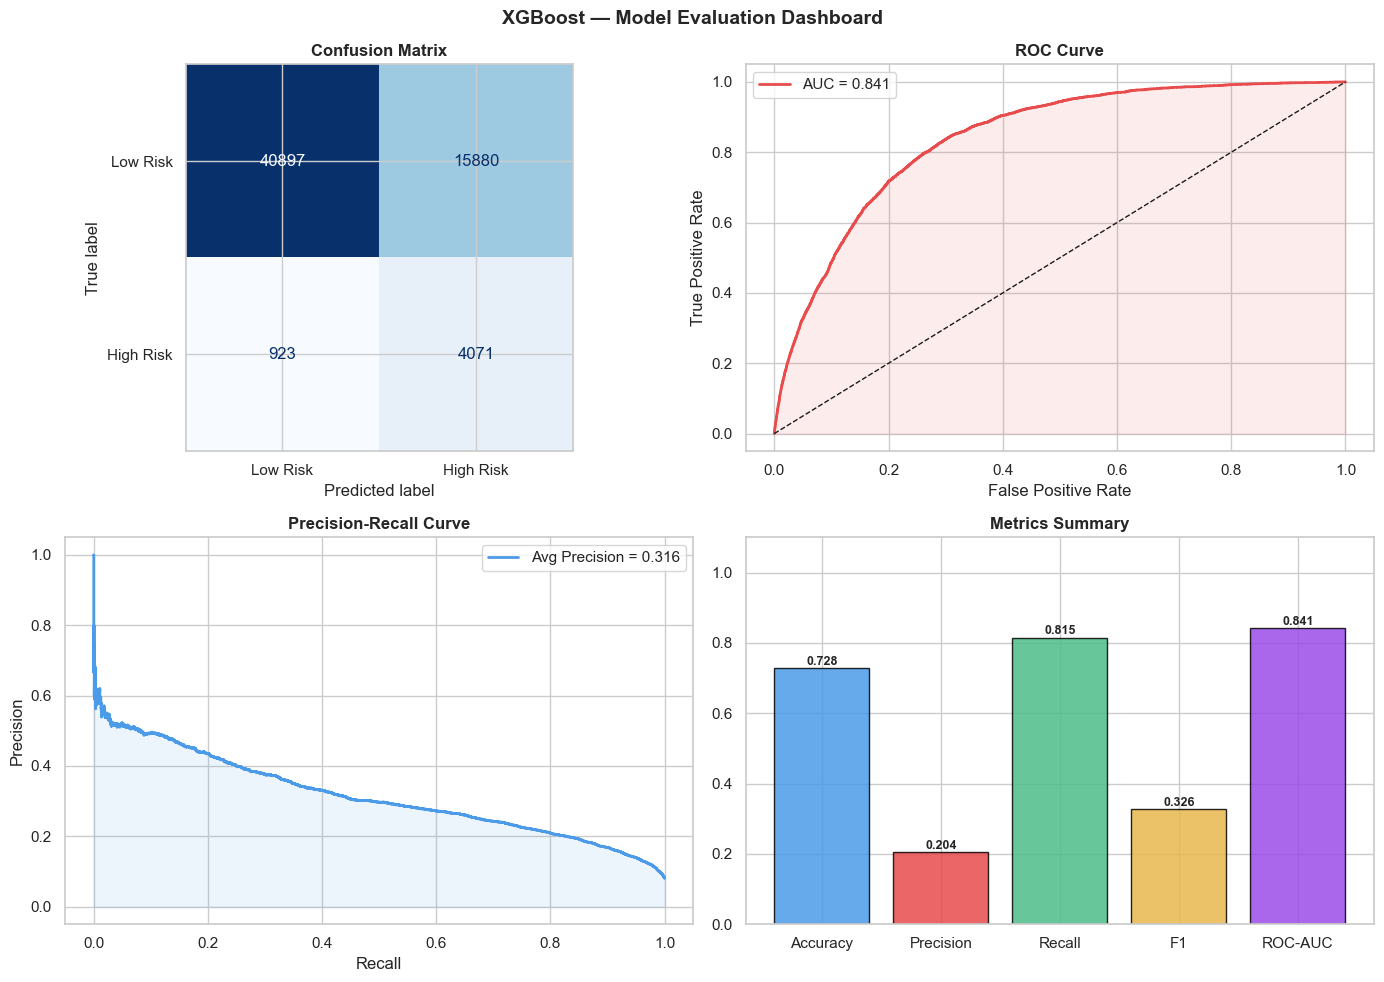

[INFO] Evaluation dashboard saved!


In [10]:
# ===========================================================
# === 10. Evaluate Model ===
# ===========================================================

# Generate predictions on test set
y_pred       = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probability of High Risk

# ---- Core metrics ----
acc     = accuracy_score(y_test, y_pred)
prec    = precision_score(y_test, y_pred,      zero_division=0)
rec     = recall_score(y_test, y_pred,         zero_division=0)
f1      = f1_score(y_test, y_pred,             zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_proba)
avg_prec= average_precision_score(y_test, y_pred_proba)

print(f"{'='*45}")
print(f"  MODEL EVALUATION RESULTS")
print(f"{'='*45}")
print(f"  Accuracy          : {acc:.4f}")
print(f"  Precision         : {prec:.4f}")
print(f"  Recall            : {rec:.4f}")
print(f"  F1 Score          : {f1:.4f}")
print(f"  ROC-AUC           : {roc_auc:.4f}")
print(f"  Avg Precision(PR) : {avg_prec:.4f}")
print(f"{'='*45}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Low Risk','High Risk'])}")

# ---- Plots ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Low Risk','High Risk']).plot(
    ax=axes[0,0], colorbar=False, cmap='Blues')
axes[0,0].set_title('Confusion Matrix', fontweight='bold')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0,1].plot(fpr, tpr, color='#E84C4C', lw=2,
               label=f'AUC = {roc_auc:.3f}')
axes[0,1].plot([0,1], [0,1], 'k--', lw=1)
axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='#E84C4C')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve', fontweight='bold')
axes[0,1].legend()

# --- Precision-Recall Curve ---
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1,0].plot(rec_vals, prec_vals, color='#4C9BE8', lw=2,
               label=f'Avg Precision = {avg_prec:.3f}')
axes[1,0].fill_between(rec_vals, prec_vals, alpha=0.1, color='#4C9BE8')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve', fontweight='bold')
axes[1,0].legend()

# --- Metric Summary Bar ---
metrics = ['Accuracy','Precision','Recall','F1','ROC-AUC']
values  = [acc, prec, rec, f1, roc_auc]
colors  = ['#4C9BE8','#E84C4C','#4CBE88','#E8B84C','#9B4CE8']
bars    = axes[1,1].bar(metrics, values, color=colors,
                         edgecolor='black', alpha=0.85)
axes[1,1].set_ylim([0, 1.1])
axes[1,1].set_title('Metrics Summary', fontweight='bold')
for bar, val in zip(bars, values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.01,
                   f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('XGBoost — Model Evaluation Dashboard',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_dashboard.png', bbox_inches='tight')
plt.show()
print("[INFO] Evaluation dashboard saved!")

--- Top 10 Most Important Features ---
        Feature  Importance
      Arthritis    0.239876
   Age_Category    0.210429
       Diabetes    0.147564
 General_Health    0.083455
            Sex    0.073508
Smoking_History    0.058679
        Checkup    0.033468
    Skin_Cancer    0.022990
     Depression    0.021800
   Other_Cancer    0.019219


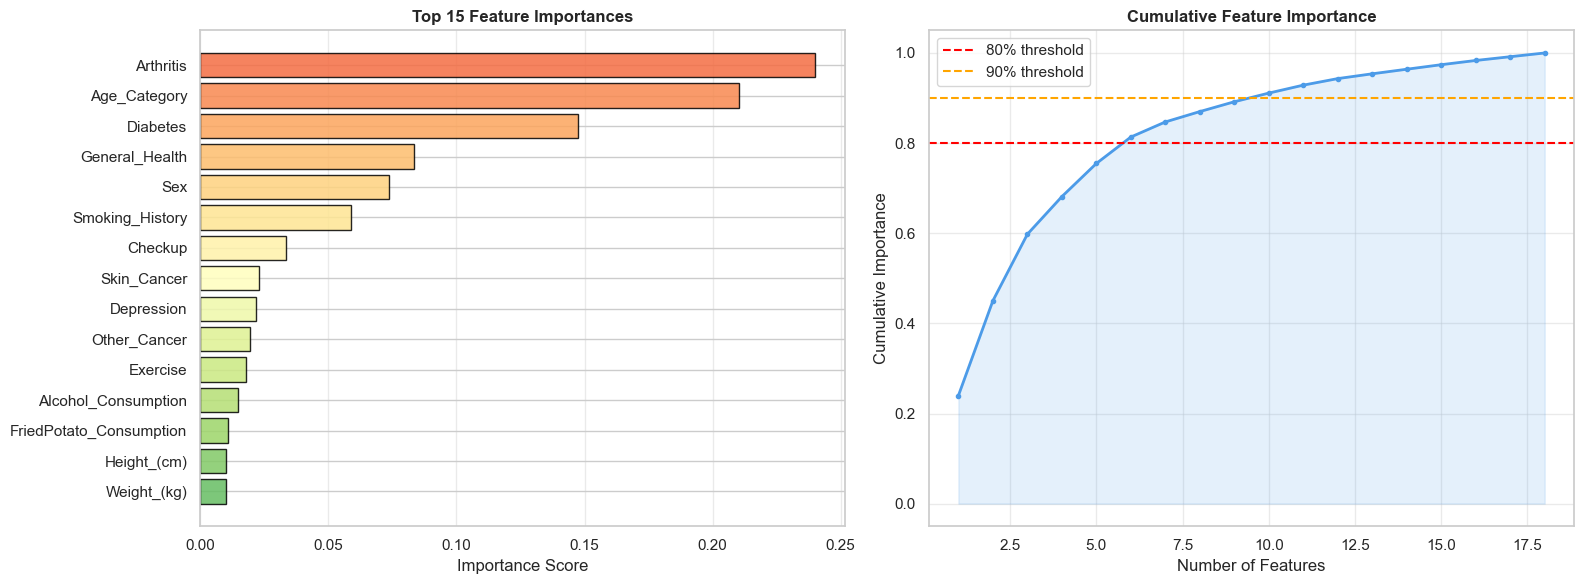

[INFO] Feature importance plot saved!

[SHAP] Generating SHAP values on 2,000 test samples...


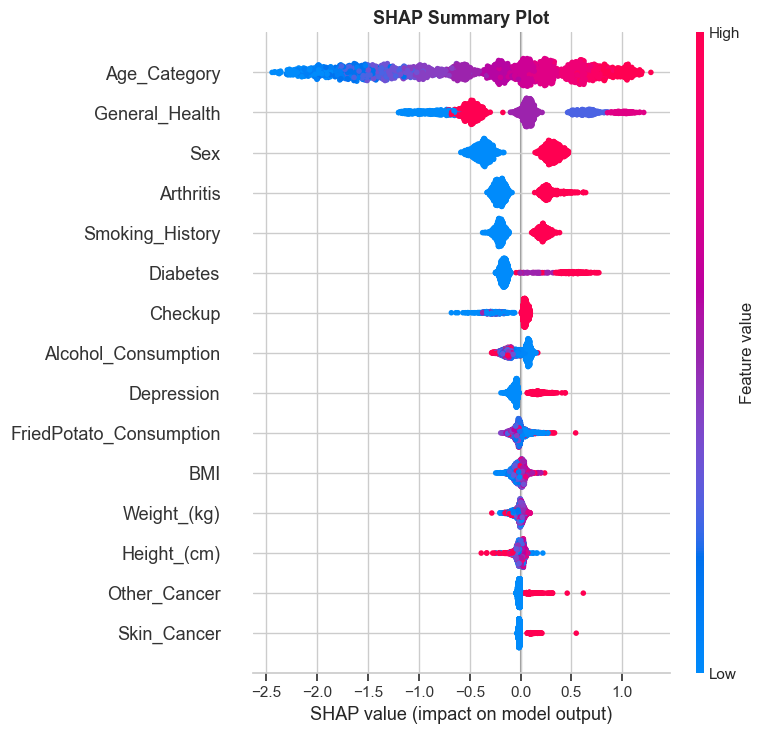

[INFO] SHAP plot saved!


In [11]:
# ===========================================================
# === 11. Feature Importance Visualization ===
# ===========================================================

# Re-check SHAP availability (in case kernel was restarted)
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

# Get feature importances from trained XGBoost model
importances  = xgb_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("--- Top 10 Most Important Features ---")
print(importance_df.head(10).to_string(index=False))

# ---- Plots ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar Chart: Top 15 features ---
top15  = importance_df.head(15)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top15)))
axes[0].barh(top15['Feature'][::-1], top15['Importance'][::-1],
             color=colors, edgecolor='black', alpha=0.85)
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Top 15 Feature Importances', fontweight='bold')
axes[0].grid(axis='x', alpha=0.4)

# --- Cumulative Importance ---
cumsum = np.cumsum(importance_df['Importance'])
axes[1].plot(range(1, len(cumsum)+1), cumsum,
             marker='o', markersize=3, color='#4C9BE8', lw=2)
axes[1].axhline(y=0.8, color='red',    linestyle='--', label='80% threshold')
axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90% threshold')
axes[1].fill_between(range(1, len(cumsum)+1), cumsum,
                     alpha=0.15, color='#4C9BE8')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title('Cumulative Feature Importance', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print("[INFO] Feature importance plot saved!")

# ---- SHAP Summary Plot (only if SHAP is installed) ----
if SHAP_AVAILABLE:
    print("\n[SHAP] Generating SHAP values on 2,000 test samples...")
    X_shap      = X_test[:2000]
    explainer   = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_shap)

    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values, X_shap,
        feature_names = feature_names,
        plot_type     = 'dot',
        show          = False,
        max_display   = 15
    )
    plt.title('SHAP Summary Plot', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_summary.png', bbox_inches='tight')
    plt.show()
    print("[INFO] SHAP plot saved!")
else:
    print("[INFO] SHAP not installed — skipping SHAP plot.")

In [12]:
# ===========================================================
# === 12. Standalone Prediction Function ===
# ===========================================================

# DISCLAIMER: For EDUCATIONAL / ACADEMIC use only.
# NOT for real medical diagnosis.
# Always consult a qualified cardiologist.

def predict_cardiovascular_risk(patient_dict, decision_threshold=0.5):
    """
    Predict cardiovascular risk for a single patient.

    Parameters
    ----------
    patient_dict       : dict — feature name → raw value
    decision_threshold : float — probability cutoff (default 0.5)

    Returns
    -------
    dict with prediction, risk label, probability, top features
    """

    # Step 1: Build feature row in correct column order
    row = {}
    for feat in FEATURE_COLS:
        row[feat] = patient_dict.get(feat, np.nan)

    # Step 2: Encode categorical features
    for col, le in label_encoders.items():
        if col in row:
            raw_val = str(row[col])
            if raw_val in le.classes_:
                row[col] = int(le.transform([raw_val])[0])
            else:
                # Unknown category → default to 0
                row[col] = 0
                print(f"  [WARN] Unknown value '{raw_val}' for '{col}' → defaulting to 0")

    # Step 3: Convert to numpy array
    x_arr = np.array(
        [row[f] for f in FEATURE_COLS],
        dtype=np.float32
    ).reshape(1, -1)

    # Step 4: Scale numerical features
    num_indices = [FEATURE_COLS.index(c) for c in numerical_cols
                   if c in FEATURE_COLS]
    x_arr[:, num_indices] = scaler.transform(x_arr[:, num_indices])

    # Step 5: Predict
    prob       = float(xgb_model.predict_proba(x_arr)[0, 1])
    prediction = int(prob >= decision_threshold)
    risk_label = 'High Risk' if prediction == 1 else 'Low Risk'

    # Step 6: Top 5 important features
    top_features = list(
        importance_df.head(5)[['Feature', 'Importance']]
        .itertuples(index=False, name=None)
    )

    return {
        'prediction'  : prediction,
        'risk_label'  : risk_label,
        'probability' : round(prob, 4),
        'confidence'  : f"{prob * 100:.1f}%",
        'top_features': top_features,
        'disclaimer'  : (
            "⚠ EDUCATIONAL USE ONLY — NOT for real medical diagnosis. "
            "Always consult a qualified cardiologist."
        )
    }

print("[INFO] predict_cardiovascular_risk() function defined successfully!")

[INFO] predict_cardiovascular_risk() function defined successfully!


In [18]:
# ===========================================================
# === 13. Demo Predictions on Sample Patients ===
# ===========================================================

# ---- High Risk Patient ----
high_risk_patient = {
    'General_Health'              : 'Poor',
    'Checkup'                     : 'Within the past year',
    'Exercise'                    : 'No',
    'Skin_Cancer'                 : 'No',
    'Other_Cancer'                : 'No',
    'Depression'                  : 'Yes',
    'Diabetes'                    : 'Yes',
    'Arthritis'                   : 'Yes',
    'Sex'                         : 'Male',
    'Age_Category'                : '70-74',
    'Height_(cm)'                 : 170.0,
    'Weight_(kg)'                 : 95.0,
    'BMI'                         : 32.9,
    'Smoking_History'             : 'Yes',
    'Alcohol_Consumption'         : 8.0,
    'Fruit_Consumption'           : 5.0,
    'Green_Vegetables_Consumption': 3.0,
    'FriedPotato_Consumption'     : 15.0,
}

# ---- Low Risk Patient ----
low_risk_patient = {
    'General_Health'              : 'Excellent',
    'Checkup'                     : 'Within the past year',
    'Exercise'                    : 'Yes',
    'Skin_Cancer'                 : 'No',
    'Other_Cancer'                : 'No',
    'Depression'                  : 'No',
    'Diabetes'                    : 'No',
    'Arthritis'                   : 'No',
    'Sex'                         : 'Female',
    'Age_Category'                : '25-29',
    'Height_(cm)'                 : 165.0,
    'Weight_(kg)'                 : 58.0,
    'BMI'                         : 21.3,
    'Smoking_History'             : 'No',
    'Alcohol_Consumption'         : 1.0,
    'Fruit_Consumption'           : 25.0,
    'Green_Vegetables_Consumption': 28.0,
    'FriedPotato_Consumption'     : 2.0,
}

# ---- Run Predictions ----
result_high = predict_cardiovascular_risk(high_risk_patient)
result_low  = predict_cardiovascular_risk(low_risk_patient)

# ---- Print Results ----
print(f"{'='*45}")
print(f"  PATIENT 1 — High Risk Example")
print(f"{'='*45}")
print(f"  Risk Label  : {result_high['risk_label']}")
print(f"  Probability : {result_high['probability']} ({result_high['confidence']})")
print(f"\n  Top 5 Important Features:")
for feat, imp in result_high['top_features']:
    print(f"    {feat:<35} : {imp:.4f}")

print(f"\n{'='*45}")
print(f"  PATIENT 2 — Low Risk Example")
print(f"{'='*45}")
print(f"  Risk Label  : {result_low['risk_label']}")
print(f"  Probability : {result_low['probability']} ({result_low['confidence']})")

  PATIENT 1 — High Risk Example
  Risk Label  : High Risk
  Probability : 0.9319 (93.2%)

  Top 5 Important Features:
    Arthritis                           : 0.2399
    Age_Category                        : 0.2104
    Diabetes                            : 0.1476
    General_Health                      : 0.0835
    Sex                                 : 0.0735

  PATIENT 2 — Low Risk Example
  Risk Label  : Low Risk
  Probability : 0.029 (2.9%)


In [14]:
# ===========================================================
# === 14. Save All Model Files into models/ Folder ===
# ===========================================================

import os

# Create models folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save all artifacts into models/ folder
joblib.dump(xgb_model,      'models/cvd_xgboost_model.joblib')
joblib.dump(scaler,         'models/cvd_scaler.joblib')
joblib.dump(label_encoders, 'models/cvd_label_encoders.joblib')
joblib.dump(feature_names,  'models/cvd_feature_names.joblib')
joblib.dump(numerical_cols, 'models/cvd_numerical_cols.joblib')
joblib.dump(FEATURE_COLS,   'models/cvd_feature_cols.joblib')

print("[INFO] All model files saved into models/ folder!")
print("\n  Saved files:")
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f"    ✅ models/{f}  ({size:.1f} KB)")

print("\n[INFO] Jupyter Notebook is complete!")
print("[INFO] You can now build the Flask app.")

[INFO] All model files saved into models/ folder!

  Saved files:
    ✅ models/cvd_feature_cols.joblib  (0.3 KB)
    ✅ models/cvd_feature_names.joblib  (0.3 KB)
    ✅ models/cvd_label_encoders.joblib  (3.7 KB)
    ✅ models/cvd_numerical_cols.joblib  (0.1 KB)
    ✅ models/cvd_scaler.joblib  (0.7 KB)
    ✅ models/cvd_xgboost_model.joblib  (732.1 KB)

[INFO] Jupyter Notebook is complete!
[INFO] You can now build the Flask app.
